Surrogate Model - SIRD симулятор
=================================
Быстрый суррогат для эпидемиологической модели SIRD
Вход: (β, γ, μ)
Выход: позиция пика (день), высота пика

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from datetime import datetime
import os
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Создаем папку для результатов
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"surrogate_results_{timestamp}"
os.makedirs(results_dir, exist_ok=True)
print(f"Результаты будут сохранены в: {results_dir}")

Результаты будут сохранены в: surrogate_results_20260428_234001


# ## 1. SIRD суррогатная модель

In [2]:
class SIRDSurrogate:
    """
    SIRD модель как суррогат для быстрого прогнозирования
    """
    
    def __init__(self, population, S0, I0, R0, D0):
        """
        Args:
            population: общая численность населения
            S0: начальное количество восприимчивых
            I0: начальное количество инфицированных
            R0: начальное количество выздоровевших
            D0: начальное количество умерших
        """
        self.population = population
        self.S0 = S0
        self.I0 = I0
        self.R0 = R0
        self.D0 = D0
        
    def ode_system(self, t, y, beta, gamma, mu):
        S, I, R, D = y
        N = self.population
        dSdt = -beta * S * I / N
        dIdt = beta * S * I / N - gamma * I - mu * I
        dRdt = gamma * I
        dDdt = mu * I
        return [dSdt, dIdt, dRdt, dDdt]
    
    def simulate(self, beta, gamma, mu, t_max=400, num_points=1000):
        """
        Симуляция SIRD модели (быстрая)
        
        Args:
            beta: скорость заражения
            gamma: скорость выздоровления
            mu: смертность
            t_max: максимальное время симуляции (дни)
            num_points: количество точек для вывода
            
        Returns:
            dict: метрики эпидемии
        """
        t_span = (0, t_max)
        t_eval = np.linspace(0, t_max, num_points)
        y0 = [self.S0, self.I0, self.R0, self.D0]
        
        try:
            # Быстрое численное решение
            solution = solve_ivp(
                self.ode_system, 
                t_span, 
                y0, 
                args=(beta, gamma, mu),
                t_eval=t_eval,
                method='RK45',
                rtol=1e-6,
                atol=1e-8
            )
            
            t = solution.t
            S, I, R, D = solution.y
            
            # Находим пик инфекции
            peak_idx = np.argmax(I)
            peak_position = t[peak_idx]  # день пика
            peak_height = I[peak_idx]     # количество инфицированных в пике
            
            # Дополнительные метрики
            final_infected = I[-1]
            total_recovered = R[-1]
            total_deaths = D[-1]
            
            return {
                'peak_position': peak_position,
                'peak_height': peak_height,
                'peak_day': int(peak_position),
                't': t,
                'I': I,
                'S': S,
                'R': R,
                'D': D,
                'final_infected': final_infected,
                'total_recovered': total_recovered,
                'total_deaths': total_deaths
            }
            
        except Exception as e:
            print(f"Ошибка симуляции для β={beta:.3f}, γ={gamma:.3f}, μ={mu:.5f}: {e}")
            return None


In [13]:
surr = SIRDSurrogate(100000, 99900, 100, 0, 0)
surr.simulate(0.1, 0.06, 0.003, t_max=1000)

{'peak_position': np.float64(161.16116116116117),
 'peak_height': np.float64(7954.735396330091),
 'peak_day': 161,
 't': array([   0.        ,    1.001001  ,    2.002002  ,    3.003003  ,
           4.004004  ,    5.00500501,    6.00600601,    7.00700701,
           8.00800801,    9.00900901,   10.01001001,   11.01101101,
          12.01201201,   13.01301301,   14.01401401,   15.01501502,
          16.01601602,   17.01701702,   18.01801802,   19.01901902,
          20.02002002,   21.02102102,   22.02202202,   23.02302302,
          24.02402402,   25.02502503,   26.02602603,   27.02702703,
          28.02802803,   29.02902903,   30.03003003,   31.03103103,
          32.03203203,   33.03303303,   34.03403403,   35.03503504,
          36.03603604,   37.03703704,   38.03803804,   39.03903904,
          40.04004004,   41.04104104,   42.04204204,   43.04304304,
          44.04404404,   45.04504505,   46.04604605,   47.04704705,
          48.04804805,   49.04904905,   50.05005005,   51.051051

# ## 2. Тестирование суррогата на разных параметрах

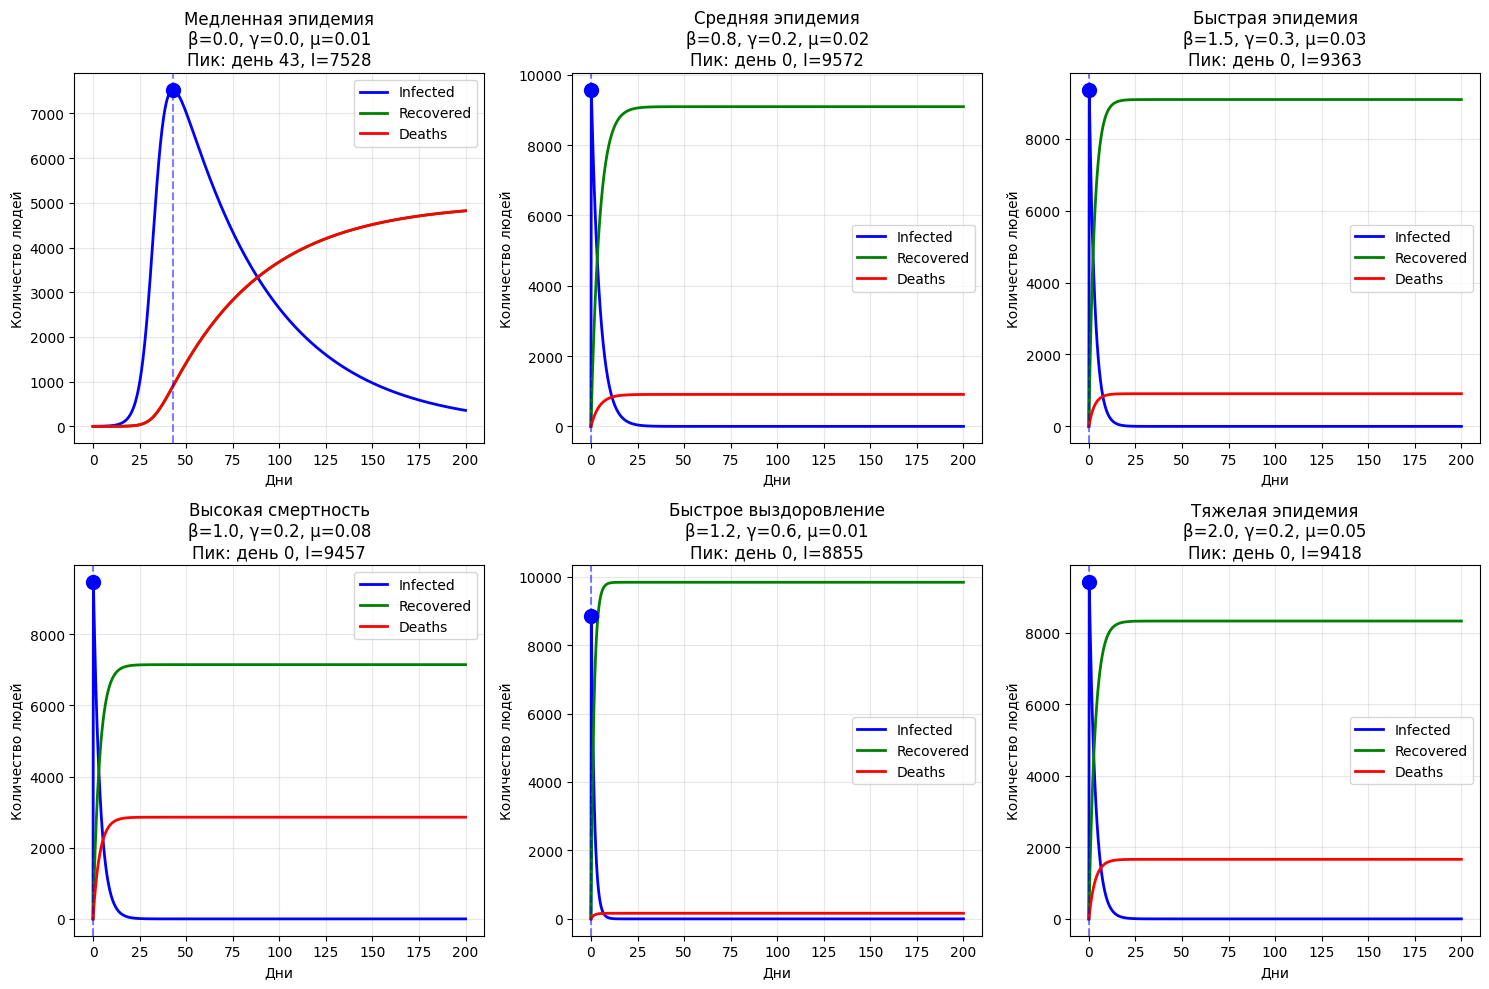


Результаты симуляций:
                 name    beta  gamma   mu  peak_position  peak_height  total_infected  total_deaths
   Медленная эпидемия 0.00003   0.01 0.01      43.043043  7527.874862     9642.683009   4821.341504
     Средняя эпидемия 0.80000   0.20 0.02       0.200200  9571.542195    10000.000000    909.090909
     Быстрая эпидемия 1.50000   0.30 0.03       0.200200  9362.587172    10000.000000    909.090909
   Высокая смертность 1.00000   0.20 0.08       0.200200  9457.300045    10000.000000   2857.142857
Быстрое выздоровление 1.20000   0.60 0.01       0.200200  8854.547696    10000.000000    163.934426
     Тяжелая эпидемия 2.00000   0.25 0.05       0.200200  9418.380858    10000.000000   1666.666667


In [16]:
def test_surrogate():
    """Тестирование SIRD суррогата с разными параметрами"""
    
    # Параметры популяции (можно менять)
    population = 10000  # 1 миллион человек
    initial_conditions = {
        'S0': 9999,  # начальные восприимчивые
        'I0': 1,      # начальные инфицированные
        'R0': 0,        # начальные выздоровевшие
        'D0': 0         # начальные умершие
    }
    
    # Создаем суррогат
    surrogate = SIRDSurrogate(
        population=population,
        S0=initial_conditions['S0'],
        I0=initial_conditions['I0'],
        R0=initial_conditions['R0'],
        D0=initial_conditions['D0']
    )
    
    # Тестовые сценарии
    test_scenarios = [
        {'name': 'Медленная эпидемия', 'beta': 0.00003, 'gamma': 0.01, 'mu': 0.01},
        {'name': 'Средняя эпидемия', 'beta': 0.8, 'gamma': 0.2, 'mu': 0.02},
        {'name': 'Быстрая эпидемия', 'beta': 1.5, 'gamma': 0.3, 'mu': 0.03},
        {'name': 'Высокая смертность', 'beta': 1.0, 'gamma': 0.2, 'mu': 0.08},
        {'name': 'Быстрое выздоровление', 'beta': 1.2, 'gamma': 0.6, 'mu': 0.01},
        {'name': 'Тяжелая эпидемия', 'beta': 2.0, 'gamma': 0.25, 'mu': 0.05}
    ]
    
    results = []
    
    # Создаем график
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, scenario in enumerate(test_scenarios):
        # Симуляция
        result = surrogate.simulate(
            beta=scenario['beta'],
            gamma=scenario['gamma'],
            mu=scenario['mu']
        )
        
        if result:
            # Сохраняем результаты
            results.append({
                'name': scenario['name'],
                'beta': scenario['beta'],
                'gamma': scenario['gamma'],
                'mu': scenario['mu'],
                'peak_position': result['peak_position'],
                'peak_height': result['peak_height'],
                'total_infected': result['total_recovered'] + result['total_deaths'],
                'total_deaths': result['total_deaths']
            })
            
            # Визуализация
            ax = axes[idx]
            ax.plot(result['t'], result['I'], 'b-', linewidth=2, label='Infected')
            ax.plot(result['t'], result['R'], 'g-', linewidth=2, label='Recovered')
            ax.plot(result['t'], result['D'], 'r-', linewidth=2, label='Deaths')
            
            # Отмечаем пик
            ax.axvline(x=result['peak_position'], color='blue', linestyle='--', alpha=0.5)
            ax.scatter(result['peak_position'], result['peak_height'], 
                      color='blue', s=100, zorder=5, marker='o')
            
            ax.set_title(f"{scenario['name']}\nβ={scenario['beta']:.1f}, γ={scenario['gamma']:.1f}, μ={scenario['mu']:.2f}\n"
                        f"Пик: день {result['peak_position']:.0f}, I={result['peak_height']:.0f}")
            ax.set_xlabel('Дни')
            ax.set_ylabel('Количество людей')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{results_dir}/test_scenarios.png", dpi=150)
    plt.show()
    
    # Выводим результаты в таблицу
    results_df = pd.DataFrame(results)
    print("\nРезультаты симуляций:")
    print(results_df.to_string(index=False))
    
    return surrogate, results_df

# Запускаем тестирование
surrogate, test_results = test_surrogate()


In [17]:
results

NameError: name 'results' is not defined

# ## 3. Исследование влияния параметров на позицию пика

Анализ влияния параметров на позицию пика...


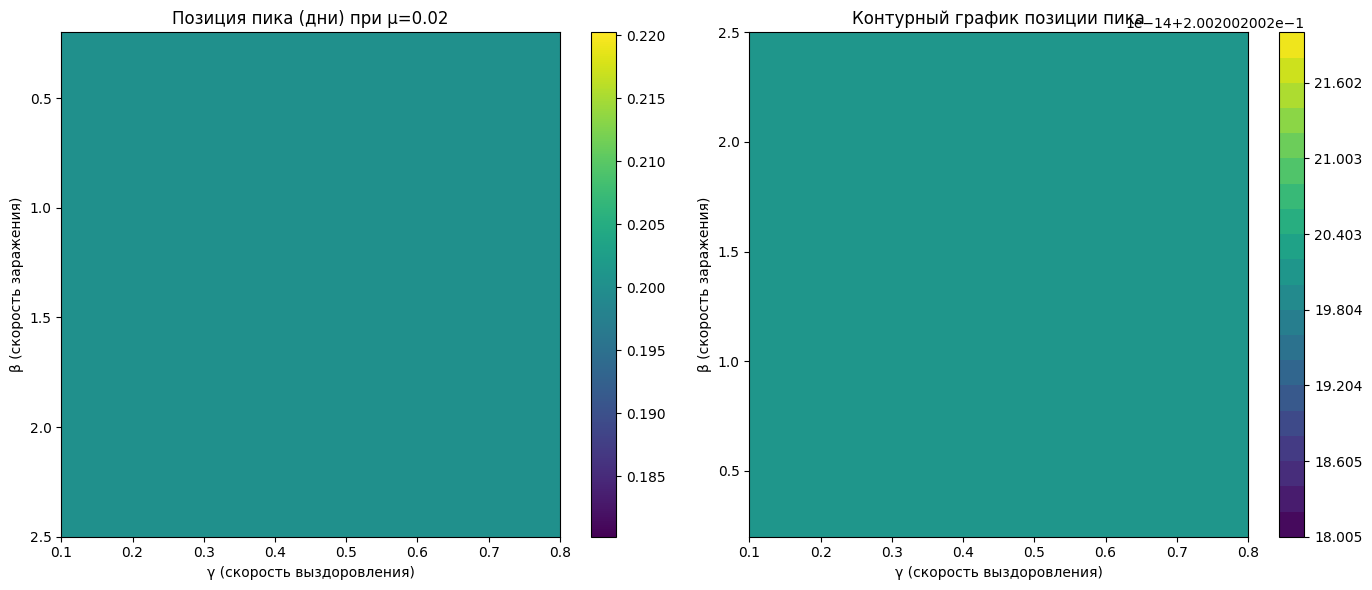

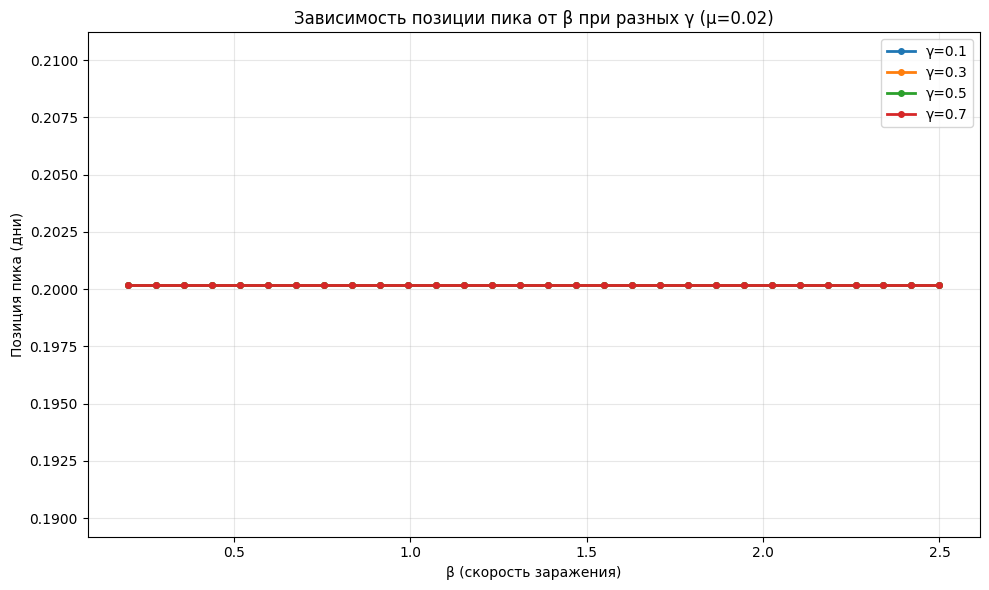

In [6]:
def analyze_peak_position(surrogate):
    """Анализ зависимости позиции пика от параметров"""
    
    # Создаем сетку параметров
    beta_range = np.linspace(0.2, 2.5, 20)
    gamma_range = np.linspace(0.1, 0.8, 20)
    mu_fixed = 0.02  # фиксированная смертность
    
    # Матрица для хранения результатов
    peak_matrix = np.zeros((len(beta_range), len(gamma_range)))
    
    print("Анализ влияния параметров на позицию пика...")
    
    for i, beta in enumerate(beta_range):
        for j, gamma in enumerate(gamma_range):
            result = surrogate.simulate(beta, gamma, mu_fixed)
            if result:
                peak_matrix[i, j] = result['peak_position']
            else:
                peak_matrix[i, j] = np.nan
    
    # Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Тепловая карта
    im = axes[0].imshow(peak_matrix, extent=[gamma_range[0], gamma_range[-1], 
                                             beta_range[-1], beta_range[0]], 
                        aspect='auto', cmap='viridis')
    axes[0].set_xlabel('γ (скорость выздоровления)')
    axes[0].set_ylabel('β (скорость заражения)')
    axes[0].set_title('Позиция пика (дни) при μ=0.02')
    plt.colorbar(im, ax=axes[0])
    
    # Контурный график
    X, Y = np.meshgrid(gamma_range, beta_range)
    contour = axes[1].contourf(X, Y, peak_matrix, levels=20, cmap='viridis')
    axes[1].set_xlabel('γ (скорость выздоровления)')
    axes[1].set_ylabel('β (скорость заражения)')
    axes[1].set_title('Контурный график позиции пика')
    plt.colorbar(contour, ax=axes[1])
    
    plt.tight_layout()
    plt.savefig(f"{results_dir}/peak_position_analysis.png", dpi=150)
    plt.show()
    
    # Анализ зависимости от β при фиксированном γ
    fig, ax = plt.subplots(figsize=(10, 6))
    
    gamma_values = [0.1, 0.3, 0.5, 0.7]
    for gamma in gamma_values:
        peaks = []
        betas = np.linspace(0.2, 2.5, 30)
        for beta in betas:
            result = surrogate.simulate(beta, gamma, mu_fixed)
            if result:
                peaks.append(result['peak_position'])
            else:
                peaks.append(np.nan)
        ax.plot(betas, peaks, label=f'γ={gamma}', linewidth=2, marker='o', markersize=4)
    
    ax.set_xlabel('β (скорость заражения)')
    ax.set_ylabel('Позиция пика (дни)')
    ax.set_title(f'Зависимость позиции пика от β при разных γ (μ={mu_fixed})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{results_dir}/beta_dependence.png", dpi=150)
    plt.show()
    
    return peak_matrix

peak_matrix = analyze_peak_position(surrogate)

# ## 4. Сравнение скорости разных реализаций

In [7]:
def speed_test():
    """Тестирование скорости суррогата"""
    import time
    
    print("\n" + "="*50)
    print("Тест скорости суррогатной модели (SIRD)")
    print("="*50)
    
    # Параметры для теста
    test_params = [
        (0.8, 0.2, 0.02),
        (1.2, 0.3, 0.03),
        (1.5, 0.4, 0.04),
        (0.5, 0.15, 0.01),
        (2.0, 0.5, 0.05)
    ]
    
    n_repeats = 1000  # количество повторений для точного замера
    
    for beta, gamma, mu in test_params:
        # Замеряем время одного вызова
        start = time.time()
        for _ in range(n_repeats):
            result = surrogate.simulate(beta, gamma, mu)
        elapsed = time.time() - start
        
        avg_time = elapsed / n_repeats * 1000  # в миллисекундах
        
        print(f"\nПараметры: β={beta:.2f}, γ={gamma:.2f}, μ={mu:.3f}")
        print(f"  Среднее время симуляции: {avg_time:.3f} мс")
        print(f"  Количество симуляций/сек: {1000/avg_time:.0f}")
        if result:
            print(f"  Пик на день: {result['peak_position']:.1f}")
    
    return

speed_test()


Тест скорости суррогатной модели (SIRD)

Параметры: β=0.80, γ=0.20, μ=0.020
  Среднее время симуляции: 50.650 мс
  Количество симуляций/сек: 20
  Пик на день: 0.2

Параметры: β=1.20, γ=0.30, μ=0.030
  Среднее время симуляции: 49.374 мс
  Количество симуляций/сек: 20
  Пик на день: 0.2

Параметры: β=1.50, γ=0.40, μ=0.040
  Среднее время симуляции: 46.610 мс
  Количество симуляций/сек: 21
  Пик на день: 0.2

Параметры: β=0.50, γ=0.15, μ=0.010
  Среднее время симуляции: 42.531 мс
  Количество симуляций/сек: 24
  Пик на день: 0.2

Параметры: β=2.00, γ=0.50, μ=0.050
  Среднее время симуляции: 51.709 мс
  Количество симуляций/сек: 19
  Пик на день: 0.2


# ## 5. Пример использования с LLM


Пример интеграции с LLM-агентом


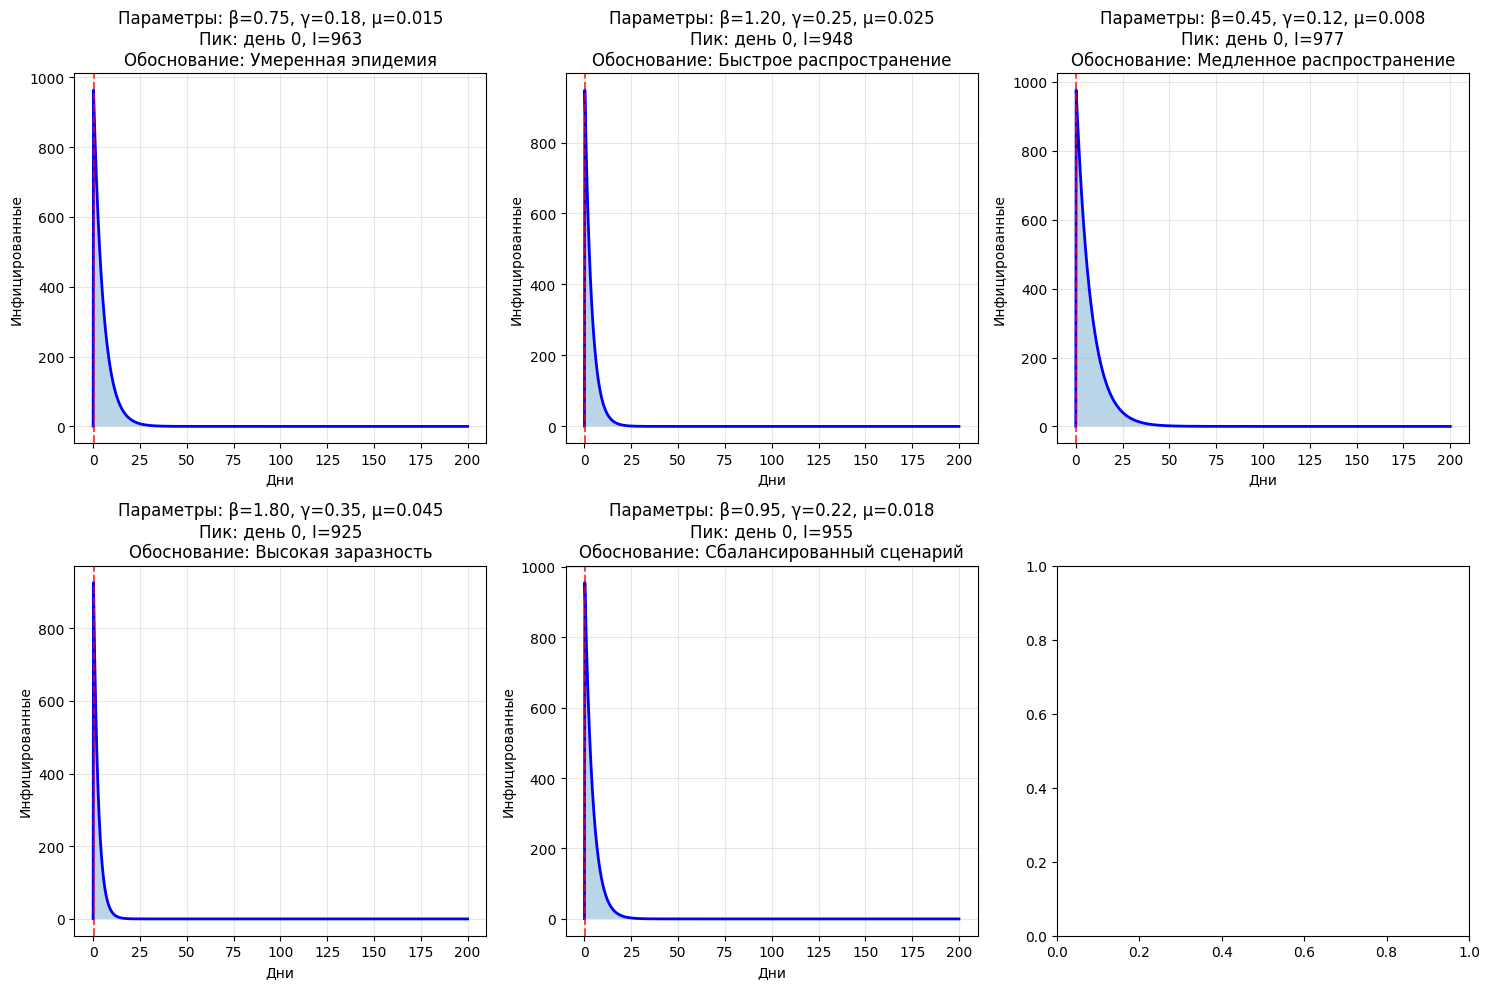


Результаты оценки LLM-сгенерированных параметров:
   β    γ     μ  peak_day  peak_height  total_deaths                 reasoning
0.75 0.18 0.015         0   963.442525     76.923077        Умеренная эпидемия
1.20 0.25 0.025         0   947.932881     90.909091   Быстрое распространение
0.45 0.12 0.008         0   976.617643     62.500000 Медленное распространение
1.80 0.35 0.045         0   925.368910    113.924051        Высокая заразность
0.95 0.22 0.018         0   955.121676     75.630252 Сбалансированный сценарий

Рекомендуемый вариант:
  {'β': 0.45, 'γ': 0.12, 'μ': 0.008, 'peak_day': 0, 'peak_height': 976.6176426662158, 'total_deaths': 62.4999999994483, 'reasoning': 'Медленное распространение'}


In [8]:
def example_llm_integration():
    """
    Пример того, как суррогат будет использоваться с LLM
    """
    
    print("\n" + "="*50)
    print("Пример интеграции с LLM-агентом")
    print("="*50)
    
    # Предположим, LLM сгенерировал такие параметры
    llm_generated_params = [
        {'beta': 0.75, 'gamma': 0.18, 'mu': 0.015, 'reasoning': 'Умеренная эпидемия'},
        {'beta': 1.2, 'gamma': 0.25, 'mu': 0.025, 'reasoning': 'Быстрое распространение'},
        {'beta': 0.45, 'gamma': 0.12, 'mu': 0.008, 'reasoning': 'Медленное распространение'},
        {'beta': 1.8, 'gamma': 0.35, 'mu': 0.045, 'reasoning': 'Высокая заразность'},
        {'beta': 0.95, 'gamma': 0.22, 'mu': 0.018, 'reasoning': 'Сбалансированный сценарий'}
    ]
    
    # Оценка каждого сгенерированного параметра
    results = []
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, params in enumerate(llm_generated_params):
        # Быстрая симуляция суррогатом
        result = surrogate.simulate(
            beta=params['beta'],
            gamma=params['gamma'],
            mu=params['mu']
        )
        
        if result:
            results.append({
                'β': params['beta'],
                'γ': params['gamma'],
                'μ': params['mu'],
                'peak_day': result['peak_day'],
                'peak_height': result['peak_height'],
                'total_deaths': result['total_deaths'],
                'reasoning': params['reasoning']
            })
            
            # Визуализация
            ax = axes[idx]
            ax.plot(result['t'], result['I'], 'b-', linewidth=2)
            ax.fill_between(result['t'], 0, result['I'], alpha=0.3)
            ax.axvline(x=result['peak_position'], color='red', linestyle='--', alpha=0.7)
            
            ax.set_title(f"Параметры: β={params['beta']:.2f}, γ={params['gamma']:.2f}, μ={params['mu']:.3f}\n"
                        f"Пик: день {result['peak_day']}, I={result['peak_height']:.0f}\n"
                        f"Обоснование: {params['reasoning']}")
            ax.set_xlabel('Дни')
            ax.set_ylabel('Инфицированные')
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{results_dir}/llm_generated_params.png", dpi=150)
    plt.show()
    
    # Выводим таблицу результатов
    results_df = pd.DataFrame(results)
    print("\nРезультаты оценки LLM-сгенерированных параметров:")
    print(results_df.to_string(index=False))
    
    # Выбираем лучший вариант (например, по минимальной смертности при разумном пике)
    best_idx = results_df['total_deaths'].idxmin()
    print(f"\nРекомендуемый вариант:")
    print(f"  {results_df.iloc[best_idx].to_dict()}")
    
    return results_df

llm_results = example_llm_integration()

# ## 6. Создание простого API для быстрого вызова

In [25]:
class FastSurrogateAPI:
    """
    Простой API для быстрого вызова суррогата из LLM
    """
    
    def __init__(self, surrogate):
        self.surrogate = surrogate
        
    def predict(self, beta, gamma, mu):
        """
        Быстрое предсказание метрик эпидемии
        
        Args:
            beta: скорость заражения
            gamma: скорость выздоровления
            mu: смертность
            
        Returns:
            dict: метрики для LLM
        """
        result = self.surrogate.simulate(beta, gamma, mu)
        
        if result:
            return {
                'success': True,
                'peak_day': result['peak_day'],
                'peak_position': result['peak_position'],
                'peak_height': result['peak_height'],
                'total_deaths': result['total_deaths'],
                'total_recovered': result['total_recovered'],
                'final_infected': result['final_infected']
            }
        else:
            return {
                'success': False,
                'error': 'Симуляция не удалась'
            }
    
    def batch_predict(self, params_list):
        """
        Пакетное предсказание для множества параметров
        
        Args:
            params_list: список кортежей (beta, gamma, mu)
            
        Returns:
            list: список результатов
        """
        results = []
        for beta, gamma, mu in params_list:
            results.append(self.predict(beta, gamma, mu))
        return results

# Создаем API
fast_api = FastSurrogateAPI(surrogate)
# Пример использования API
print("\n" + "="*50)
print("Пример использования API:")
print("="*50)

test_params = [
    (0.000008, 0.02, 0.02),
    (1.2, 0.3, 0.03),
    (1.5, 0.4, 0.04)
]

for beta, gamma, mu in test_params:
    result = fast_api.predict(beta, gamma, mu)
    if result['success']:
        print(f"\nβ={beta:.2f}, γ={gamma:.2f}, μ={mu:.3f}:")
        print(f"  Пик на день {result['peak_day']} с {result['peak_height']:.0f} инфекциями")
        print(f"  Всего смертей: {result['total_deaths']:.0f}")


Пример использования API:

β=0.00, γ=0.02, μ=0.020:
  Пик на день 200 с 1269 инфекциями
  Всего смертей: 959

β=1.20, γ=0.30, μ=0.030:
  Пик на день 0 с 9363 инфекциями
  Всего смертей: 909

β=1.50, γ=0.40, μ=0.040:
  Пик на день 0 с 9159 инфекциями
  Всего смертей: 909


In [21]:
result

{'success': True,
 'peak_day': 0,
 'peak_position': np.float64(0.2002002002002002),
 'peak_height': np.float64(9159.27643838804),
 'total_deaths': np.float64(909.090909090558),
 'total_recovered': np.float64(9090.909090905563),
 'final_infected': np.float64(3.920610251885709e-09)}

# ## 7. Сохранение конфигурации суррогата

In [10]:
def save_surrogate_config(surrogate, results_dir):
    """Сохранение конфигурации суррогата"""
    
    config = {
        'population': surrogate.population,
        'S0': surrogate.S0,
        'I0': surrogate.I0,
        'R0': surrogate.R0,
        'D0': surrogate.D0,
        'description': 'SIRD surrogate model for fast epidemic simulation',
        'timestamp': timestamp
    }
    
    import json
    with open(f"{results_dir}/surrogate_config.json", 'w') as f:
        json.dump(config, f, indent=2)
    
    print(f"\nКонфигурация сохранена в {results_dir}/surrogate_config.json")

save_surrogate_config(surrogate, results_dir)



Конфигурация сохранена в surrogate_results_20260325_152850/surrogate_config.json
